# Executive Business Summary

## Objective

Consolidate the most important findings from the customer, product, seller, revenue, and delivery analyses into a concise set of business priorities and recommendations.

This notebook does not introduce major new analysis. Instead, it translates the completed analytical work into decision-ready business insights.

## Executive Overview

The analysis identified strong commercial performance across several product categories and seller groups, while also revealing operational risks related to delivery reliability, customer satisfaction, and seller performance.

The marketplace demonstrates healthy sales activity and broad seller participation, but revenue and customer experience are not evenly distributed across categories or sellers.

The strongest growth opportunities lie in protecting high-performing categories, improving high-revenue areas with weaker customer satisfaction, strengthening seller delivery performance, and using customer feedback more systematically to guide operational improvements.

## Key Business Indicators

- **Top revenue category:** Health & Beauty
- **Highest-volume category:** Bed Bath Table
- **Top 10 sellers' revenue share:** ~13.15%
- **Sellers generating ~80% of item revenue:** 544
- **Late-delivery vs seller review correlation:** ~-0.52
- **Delivery duration vs seller review correlation:** ~-0.57

## Customer Experience

Customer reviews indicate that delivery performance, product expectations, and order fulfilment are important drivers of dissatisfaction.

One-star review analysis showed recurring complaints related to logistics and product experience, while highly rated reviews highlighted successful fulfilment and product satisfaction.

Customer feedback should therefore be treated as an operational KPI rather than only a post-purchase metric.

## Commercial Performance

Health & Beauty generates the highest overall category revenue while maintaining relatively strong customer satisfaction.

Bed Bath Table is one of the strongest categories by unit volume but performs below the overall average review score.

Watches & Gifts generates high revenue despite lower unit volume, reflecting a higher-value product mix.

Office Furniture stands out as a category requiring further attention because it combines weaker customer satisfaction with relatively costly and slower fulfilment.

Highly rated categories such as Books, Food & Drink, and Luggage Accessories represent opportunities for promotion, cross-selling, and customer-retention activity.

## Seller and Delivery Performance

Seller activity is heavily concentrated in São Paulo, which accounts for the majority of marketplace sellers and order volume.

Several established sellers show late-delivery rates above 20%, highlighting operational variation across the marketplace.

Seller late-delivery rate shows a moderate negative association with average customer review score (approximately -0.52), while average delivery duration shows a similar negative relationship (approximately -0.57).

The top 10 sellers generate approximately 13.15% of item revenue, while around 544 sellers account for approximately 80% of item revenue. This suggests meaningful seller concentration without excessive dependence on only a handful of partners.

## Strategic Recommendations

1. Protect high-performing categories that combine strong revenue, volume, and customer satisfaction.

2. Prioritise improvement efforts in high-revenue categories and sellers with below-average customer ratings.

3. Introduce a seller scorecard combining revenue, order volume, review score, late-delivery rate, delivery time, and freight cost.

4. Investigate sellers with persistently high late-delivery rates and identify whether the root cause is stock availability, seller handling time, carrier performance, or delivery geography.

5. Use customer review themes as an operational monitoring tool to identify recurring fulfilment and product-quality issues.

6. Increase promotion and cross-selling around highly rated categories with meaningful order volume.

7. Improve inventory and promotional planning around observed seasonal demand patterns.

8. Monitor category and seller performance over time rather than relying only on lifetime averages.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

if (Path.cwd() / "data" / "raw").exists():
    DATA_PATH = Path.cwd() / "data" / "raw"
elif (Path.cwd().parent / "data" / "raw").exists():
    DATA_PATH = Path.cwd().parent / "data" / "raw"
else:
    raise FileNotFoundError("Could not find the data/raw folder.")

customers = pd.read_csv(DATA_PATH / "olist_customers_dataset.csv")
orders = pd.read_csv(DATA_PATH / "olist_orders_dataset.csv")
order_items = pd.read_csv(DATA_PATH / "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_PATH / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_PATH / "olist_order_reviews_dataset.csv")
products = pd.read_csv(DATA_PATH / "olist_products_dataset.csv")
sellers = pd.read_csv(DATA_PATH / "olist_sellers_dataset.csv")
geolocation = pd.read_csv(DATA_PATH / "olist_geolocation_dataset.csv")
category_translation = pd.read_csv(
    DATA_PATH / "product_category_name_translation.csv"
)

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [2]:
category_sales = (
    order_items
    .merge(
        products[
            ["product_id", "product_category_name"]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        category_translation,
        on="product_category_name",
        how="left"
    )
)

category_revenue = (
    category_sales
    .groupby("product_category_name_english")
    .agg(
        revenue=("price", "sum"),
        units_sold=("order_item_id", "count")
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

top_categories = (
    category_revenue
    .head(10)
    .sort_values("revenue")
)

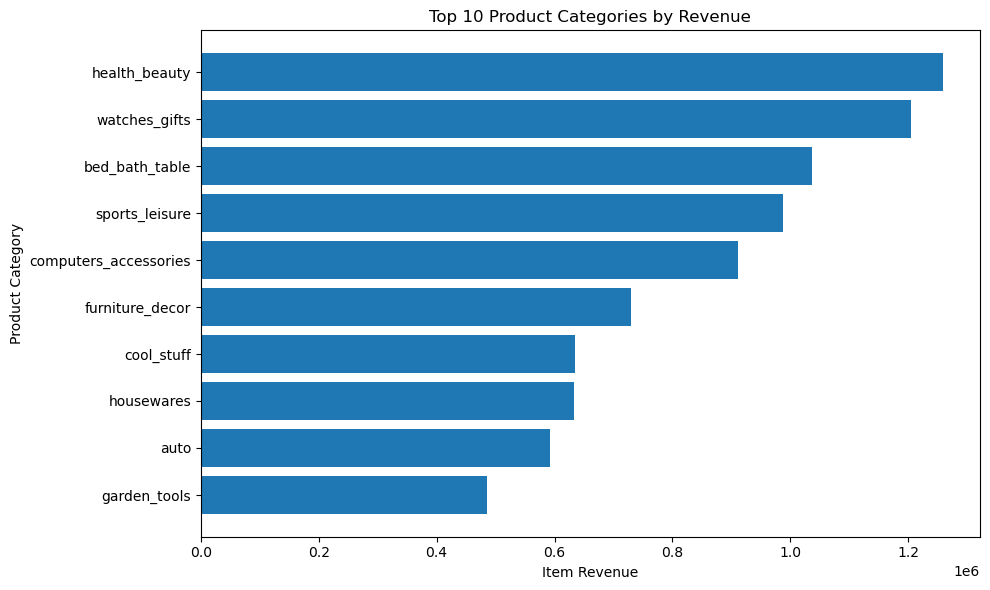

In [3]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_categories["product_category_name_english"],
    top_categories["revenue"]
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Item Revenue")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

### Commercial Highlight

Health & Beauty, Watches & Gifts, and Bed Bath Table are among the largest revenue contributors.

The result also shows why revenue and sales volume should be evaluated separately: some categories generate strong revenue through higher-value products rather than exceptionally high unit volume.

In [4]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"],
    errors="coerce"
)

monthly_data = (
    order_items
    .merge(
        orders[
            ["order_id", "order_purchase_timestamp"]
        ],
        on="order_id",
        how="left"
    )
)

monthly_data["purchase_month"] = (
    monthly_data["order_purchase_timestamp"]
    .dt.to_period("M")
)

monthly_revenue = (
    monthly_data
    .groupby("purchase_month")
    .agg(
        revenue=("price", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

monthly_revenue["purchase_month"] = (
    monthly_revenue["purchase_month"].astype(str)
)

monthly_revenue_complete = monthly_revenue[
    ~monthly_revenue["purchase_month"].isin(
        ["2016-09", "2016-12", "2018-09"]
    )
].copy()

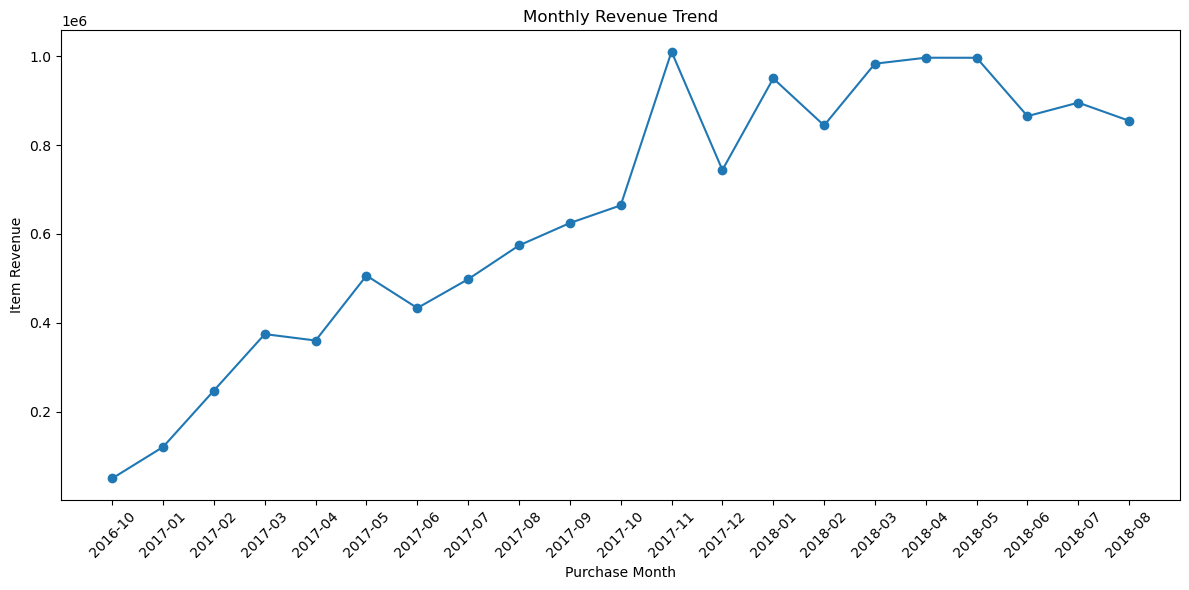

In [5]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue_complete["purchase_month"],
    monthly_revenue_complete["revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Purchase Month")
plt.ylabel("Item Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Revenue Trend

Revenue increased substantially during the analysed period, with a pronounced peak in late 2017.

The pattern suggests seasonal demand and promotional effects, particularly around the November shopping period. Incomplete edge months were excluded to avoid presenting partial data as genuine performance declines.

In [6]:
seller_orders = (
    order_items
    .groupby(["seller_id", "order_id"])
    .agg(
        revenue=("price", "sum"),
        units_sold=("order_item_id", "count")
    )
    .reset_index()
)

In [7]:
order_reviews = (
    reviews
    .groupby("order_id")
    .agg(
        review_score=("review_score", "mean")
    )
    .reset_index()
)

In [8]:
seller_analysis = (
    seller_orders
    .merge(
        orders[
            [
                "order_id",
                "order_delivered_customer_date",
                "order_estimated_delivery_date"
            ]
        ],
        on="order_id",
        how="left"
    )
    .merge(
        order_reviews,
        on="order_id",
        how="left"
    )
)

In [9]:
seller_analysis["order_delivered_customer_date"] = pd.to_datetime(
    seller_analysis["order_delivered_customer_date"],
    errors="coerce"
)

seller_analysis["order_estimated_delivery_date"] = pd.to_datetime(
    seller_analysis["order_estimated_delivery_date"],
    errors="coerce"
)

In [10]:
seller_analysis["late_delivery"] = np.where(
    seller_analysis["order_delivered_customer_date"].isna(),
    np.nan,
    (
        seller_analysis["order_delivered_customer_date"]
        > seller_analysis["order_estimated_delivery_date"]
    ).astype(float)
)

In [11]:
seller_summary = (
    seller_analysis
    .groupby("seller_id")
    .agg(
        orders=("order_id", "nunique"),
        avg_review_score=("review_score", "mean"),
        late_delivery_rate=("late_delivery", "mean")
    )
    .reset_index()
)

seller_summary["late_delivery_pct"] = (
    seller_summary["late_delivery_rate"] * 100
)

established_sellers = seller_summary[
    seller_summary["orders"] >= 50
].copy()

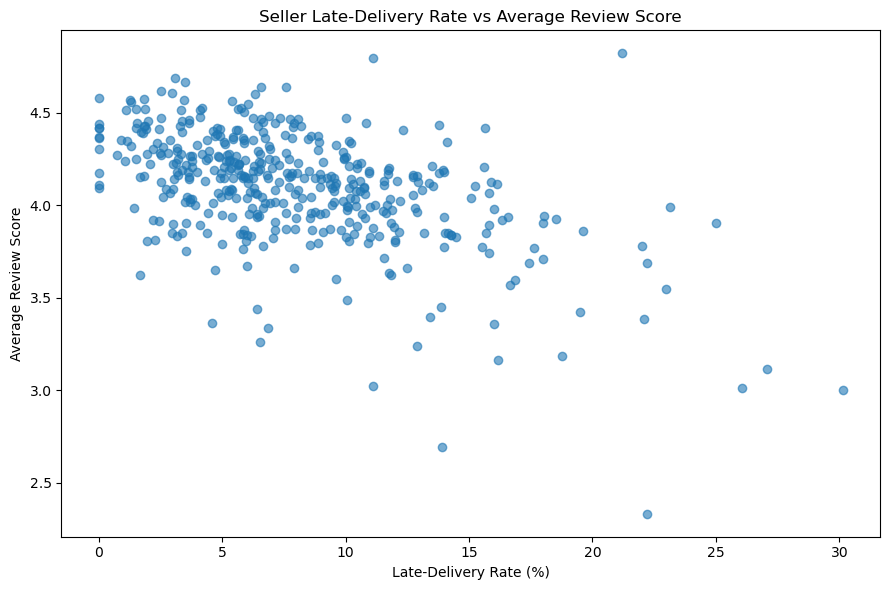

In [12]:
plt.figure(figsize=(9, 6))

plt.scatter(
    established_sellers["late_delivery_pct"],
    established_sellers["avg_review_score"],
    alpha=0.6
)

plt.title("Seller Late-Delivery Rate vs Average Review Score")
plt.xlabel("Late-Delivery Rate (%)")
plt.ylabel("Average Review Score")

plt.tight_layout()
plt.show()

### Operational Highlight

Seller delivery reliability shows a meaningful association with customer experience.

Across established sellers, higher late-delivery rates are generally associated with weaker average review scores. The seller-level correlation identified in the detailed analysis was approximately **-0.52**.

This does not establish causation, but it provides strong evidence that delivery reliability should be included in seller-performance monitoring.